# 04 — Leakage-safe models

**Input:** `data/analysis_panel_wages.csv`  
**Function:** compare linear and gradient-boosted models on sponsor-disjoint holdouts,
test forward transfer to FY2022, explain predictions, and isolate the contribution of
DOL wage features  
**Outputs:** `output/figures/06`–`09`, `13`–`14`; model, split, coefficient, and feature-
importance tables in `output/tables/`

The design answers three questions: how well employer characteristics predict outcomes
for entirely unseen sponsors, whether patterns learned before FY2022 transfer into that
year, and whether DOL wage information improves prediction on an identical matched sample.

In [1]:
import sys
from pathlib import Path

# Locate the repository root by walking up until code/src is found, then put the
# code directory on the path. No absolute paths, so this runs from any checkout.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "code" / "src").is_dir())
sys.path.insert(0, str(_root / "code"))

import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

from src import (DATA, TABLES, MODEL_YEARS, finish, save,
                 C1, C2, SEQ, INK, INK2, MUTED)

warnings.filterwarnings("ignore")
SEED = 45

## Functions and feature definitions

The rate models are weighted by the number of initial petitions because a proportion
based on 100 adjudications is measured more precisely than a proportion based on one.
WLS confidence intervals are clustered by canonical employer to allow correlation across
years. The any-denial classifiers remain employer-year models and are evaluated with AUC.

In [2]:
NUMERIC = ["log_initial", "continuing_share", "log_prev_initial",
           "prev_denial_rate", "prior_active_years", "is_repeat_sponsor"]
CATEG = ["sector", "state_grp", "fy_cat"]

WAGE_NUM = ["wage_ratio_med", "log_wage_annual", "share_low_level",
            "share_agent", "share_dependent", "log_lca_filings"]
WAGE_CAT = ["soc2_modal"]

PRETTY = {
    "log_initial": "log(1 + initial petitions)",
    "continuing_share": "Continuing (renewal) share",
    "log_prev_initial": "log(1 + prior-yr initial petitions)",
    "prev_denial_rate": "Prior-year denial rate",
    "prior_active_years": "Prior active sponsor-years",
    "is_repeat_sponsor": "Sponsored in prior year",
    "wage_ratio_med": "Offered / prevailing wage",
    "log_wage_annual": "log(median offered wage)",
    "share_low_level": "Position share at PW level I or II",
    "share_agent": "Share filed via agent or attorney",
    "share_dependent": "Share at H-1B dependent employer",
    "log_lca_filings": "log(1 + LCA filings)",
}

SHAP_NAMES = dict(PRETTY)
SHAP_NAMES.update({"fy_cat": "Fiscal year", "sector": "Industry sector",
                   "state_grp": "State", "soc2_modal": "Modal SOC group"})


def design_matrices(frame, numeric, categorical):
    '''Create one-hot linear and native-categorical LightGBM designs.'''
    X_lin = pd.get_dummies(frame[numeric + categorical],
                           columns=categorical, drop_first=True).astype(float)
    X_gbm = frame[numeric + categorical].copy()
    for c in categorical:
        X_gbm[c] = X_gbm[c].astype("category")
    return X_lin, X_gbm


def group_partitions(frame):
    '''Create 56/14/30 train/validation/test rows with disjoint employer keys.'''
    outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    dev, test = next(outer.split(frame, groups=frame.key))
    inner = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED + 1)
    train_rel, val_rel = next(inner.split(frame.iloc[dev], groups=frame.iloc[dev].key))
    train, val = dev[train_rel], dev[val_rel]
    return np.asarray(train), np.asarray(val), np.asarray(test)


def split_diagnostic(frame, train, val, test, label):
    '''Verify key separation and report fiscal-year balance.'''
    parts = {"train": train, "validation": val, "test": test}
    keys = {name: set(frame.iloc[idx].key) for name, idx in parts.items()}
    assert not (keys["train"] & keys["validation"])
    assert not (keys["train"] & keys["test"])
    assert not (keys["validation"] & keys["test"])
    out = []
    print(label)
    for name, idx in parts.items():
        print(f"  {name:10s} rows={len(idx):,} employers={frame.iloc[idx].key.nunique():,}")
        shares = frame.iloc[idx].fy.value_counts(normalize=True).sort_index()
        for fy, share in shares.items():
            out.append({"sample": label, "partition": name, "fy": fy,
                        "rows": len(idx), "employers": frame.iloc[idx].key.nunique(),
                        "year_share": share})
    print("  employer overlap across partitions: 0")
    return pd.DataFrame(out)


def lgb_regressor(**kw):
    params = dict(n_estimators=1000, learning_rate=0.04, num_leaves=48,
                  min_child_samples=50, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, random_state=SEED, verbose=-1)
    params.update(kw)
    return lgb.LGBMRegressor(**params)


def lgb_classifier(**kw):
    params = dict(n_estimators=1000, learning_rate=0.04, num_leaves=48,
                  min_child_samples=50, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, random_state=SEED, verbose=-1)
    params.update(kw)
    return lgb.LGBMClassifier(**params)


def fit_wls(X, y, weights, groups, idx):
    '''Petition-weighted rate model with employer-clustered covariance.'''
    exog = sm.add_constant(X.iloc[idx], has_constant="add")
    return sm.WLS(y[idx], exog, weights=weights[idx]).fit(
        cov_type="cluster", cov_kwds={"groups": groups[idx]})


def tune_refit_regressor(X, y, weights, train, val, dev):
    '''Choose tree count on validation data, then refit on development rows.'''
    tuned = lgb_regressor()
    tuned.fit(X.iloc[train], y[train], sample_weight=weights[train],
              eval_set=[(X.iloc[val], y[val])], eval_sample_weight=[weights[val]],
              callbacks=[lgb.early_stopping(60, verbose=False)])
    best = int(tuned.best_iteration_ or tuned.n_estimators)
    final = lgb_regressor(n_estimators=best)
    final.fit(X.iloc[dev], y[dev], sample_weight=weights[dev])
    return final, best


def tune_refit_classifier(X, y, train, val, dev):
    '''Tune only on validation data; never expose the test labels to training.'''
    tuned = lgb_classifier()
    tuned.fit(X.iloc[train], y[train], eval_set=[(X.iloc[val], y[val])],
              callbacks=[lgb.early_stopping(60, verbose=False)])
    best = int(tuned.best_iteration_ or tuned.n_estimators)
    final = lgb_classifier(n_estimators=best)
    final.fit(X.iloc[dev], y[dev])
    return final, best


def forest_plot(res, labels, title, subtitle, xlab, name):
    '''Coefficient plot with clustered 95% confidence intervals.'''
    fig, ax = plt.subplots(figsize=(7.8, 0.34 * len(res) + 1.8))
    ypos = np.arange(len(res))[::-1]
    sig = res.p < 0.05
    ax.hlines(ypos, res.lo, res.hi, color=np.where(sig, C1, MUTED), lw=2)
    ax.scatter(res.coef, ypos, s=34, color=np.where(sig, C1, MUTED), zorder=3)
    ax.axvline(0, color=INK2, lw=1, ls="--")
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    finish(ax, title, subtitle, xlab, None, grid="x")
    save(name)

## 1. Sponsor-disjoint modeling sample

FY2023 is partial and DOL coverage ends in FY2022. A sponsor's rows appear in exactly one
of train, validation, or test. This prevents the model from seeing the same employer in
training and testing, even in different years. Validation selects the LightGBM tree count;
the untouched test set is used once for final scores.

In [3]:
panel = pd.read_csv(DATA / "analysis_panel_wages.csv", low_memory=False)
fit_df = panel[panel.fy.isin(MODEL_YEARS)].copy().reset_index(drop=True)
fit_df["fy_cat"] = fit_df.fy.astype(str)

y = fit_df.denial_rate.to_numpy()
y_bin = fit_df.any_denial.to_numpy()
weights = fit_df.initial_total.to_numpy(dtype=float)
groups = fit_df.key.to_numpy()
X_lin, X_gbm = design_matrices(fit_df, NUMERIC, CATEG)

tr, va, te = group_partitions(fit_df)
dev = np.sort(np.concatenate([tr, va]))
split_base = split_diagnostic(fit_df, tr, va, te, "all employer-years")
split_base.to_csv(TABLES / "split_diagnostics.csv", index=False)

print(f"\nmodeling rows: {len(fit_df):,}; unique employer-years: "
      f"{fit_df[['key', 'fy']].drop_duplicates().shape[0]:,}")
print(f"linear design columns: {X_lin.shape[1]}")
print(f"petition-weighted denial rate, development: "
      f"{np.average(y[dev], weights=weights[dev]):.4f}; "
      f"test: {np.average(y[te], weights=weights[te]):.4f}")

all employer-years
  train      rows=92,368 employers=54,387
  validation rows=23,528 employers=13,597
  test       rows=49,697 employers=29,137
  employer overlap across partitions: 0

modeling rows: 165,593; unique employer-years: 165,593
linear design columns: 43
petition-weighted denial rate, development: 0.1239; test: 0.1379


## 2. Initial-denial rate

The held-out $R^2$ is petition-weighted, matching both the WLS objective and the fact
that employer-year rates have unequal denominators.

In [4]:
wls = fit_wls(X_lin, y, weights, groups, dev)
wls_pred = wls.predict(sm.add_constant(X_lin.iloc[te], has_constant="add"))
r2_wls = r2_score(y[te], wls_pred, sample_weight=weights[te])

gbm, best_reg = tune_refit_regressor(X_gbm, y, weights, tr, va, dev)
gbm_pred = gbm.predict(X_gbm.iloc[te])
r2_gbm = r2_score(y[te], gbm_pred, sample_weight=weights[te])

print(f"WLS development R2: {wls.rsquared:.4f}")
print(f"held-out petition-weighted R2: WLS={r2_wls:.4f}; "
      f"LightGBM={r2_gbm:.4f} (validation-selected trees={best_reg})")

WLS development R2: 0.3057
held-out petition-weighted R2: WLS=0.2957; LightGBM=0.4187 (validation-selected trees=171)


## 3. Any initial denial

The binary task complements the noisy rate outcome. It asks whether an unseen employer-
year experiences at least one denial, not how many petitions are denied.

In [5]:
logit = LogisticRegression(max_iter=3000, C=1.0)
logit.fit(X_lin.iloc[dev], y_bin[dev])
auc_logit = roc_auc_score(y_bin[te], logit.predict_proba(X_lin.iloc[te])[:, 1])

clf, best_clf = tune_refit_classifier(X_gbm, y_bin, tr, va, dev)
auc_gbm = roc_auc_score(y_bin[te], clf.predict_proba(X_gbm.iloc[te])[:, 1])

comp = pd.DataFrame({
    "Model": ["WLS (linear)", "LightGBM (gradient boosting)",
              "Logistic (linear)", "LightGBM classifier"],
    "Target": ["Initial denial rate"] * 2 + ["Any initial denial (0/1)"] * 2,
    "Metric": ["Petition-weighted R2", "Petition-weighted R2", "ROC AUC", "ROC AUC"],
    "Held-out score": [round(r2_wls, 4), round(r2_gbm, 4),
                       round(auc_logit, 4), round(auc_gbm, 4)],
})
comp.to_csv(TABLES / "model_comparison.csv", index=False)
print(f"AUC: logistic={auc_logit:.4f}; LightGBM={auc_gbm:.4f} "
      f"(validation-selected trees={best_clf})")
print("\n" + comp.to_string(index=False))

AUC: logistic=0.7884; LightGBM=0.7973 (validation-selected trees=163)

                       Model                   Target               Metric  Held-out score
                WLS (linear)      Initial denial rate Petition-weighted R2          0.2957
LightGBM (gradient boosting)      Initial denial rate Petition-weighted R2          0.4187
           Logistic (linear) Any initial denial (0/1)              ROC AUC          0.7884
         LightGBM classifier Any initial denial (0/1)              ROC AUC          0.7973


## 4. Forward validation: train through FY2021, test FY2022

Fiscal-year indicators are removed because an unseen year has no estimable dummy. Model
complexity is selected using FY2021 only: LightGBM first fits FY2017–FY2020, then refits
with the selected tree count on FY2017–FY2021. FY2022 remains untouched until scoring.

In [6]:
pre_t = np.where(fit_df.fy <= 2020)[0]
val_t = np.where(fit_df.fy == 2021)[0]
dev_t = np.where(fit_df.fy <= 2021)[0]
te_t = np.where(fit_df.fy == 2022)[0]
Xl_t = X_lin[[c for c in X_lin.columns if not c.startswith("fy_cat_")]]
Xg_t = X_gbm.drop(columns=["fy_cat"])

wls_t = fit_wls(Xl_t, y, weights, groups, dev_t)
pred_wls_t = wls_t.predict(sm.add_constant(Xl_t.iloc[te_t], has_constant="add"))
r2_wls_t = r2_score(y[te_t], pred_wls_t, sample_weight=weights[te_t])

gbm_t, best_t = tune_refit_regressor(
    Xg_t, y, weights, pre_t, val_t, dev_t)
pred_gbm_t = gbm_t.predict(Xg_t.iloc[te_t])
r2_gbm_t = r2_score(y[te_t], pred_gbm_t, sample_weight=weights[te_t])

temporal_metrics = pd.DataFrame({
    "model": ["WLS", "LightGBM"],
    "train_years": ["2017-2021", "2017-2021"],
    "validation_year": ["none", "2021"],
    "test_year": [2022, 2022],
    "metric": ["Petition-weighted R2"] * 2,
    "score": [r2_wls_t, r2_gbm_t],
})
temporal_metrics.to_csv(TABLES / "temporal_model_comparison.csv", index=False)
print(temporal_metrics.round(4).to_string(index=False))
print(f"\nweighted denial rate: development="
      f"{np.average(y[dev_t], weights=weights[dev_t]):.4f}; "
      f"FY2022={np.average(y[te_t], weights=weights[te_t]):.4f}")
print(f"LightGBM validation-selected trees: {best_t}")

   model train_years validation_year  test_year               metric   score
     WLS   2017-2021            none       2022 Petition-weighted R2 -1.7203
LightGBM   2017-2021            2021       2022 Petition-weighted R2 -1.2398

weighted denial rate: development=0.1497; FY2022=0.0221
LightGBM validation-selected trees: 16


findfont: Failed to find font weight 600, now using 700.


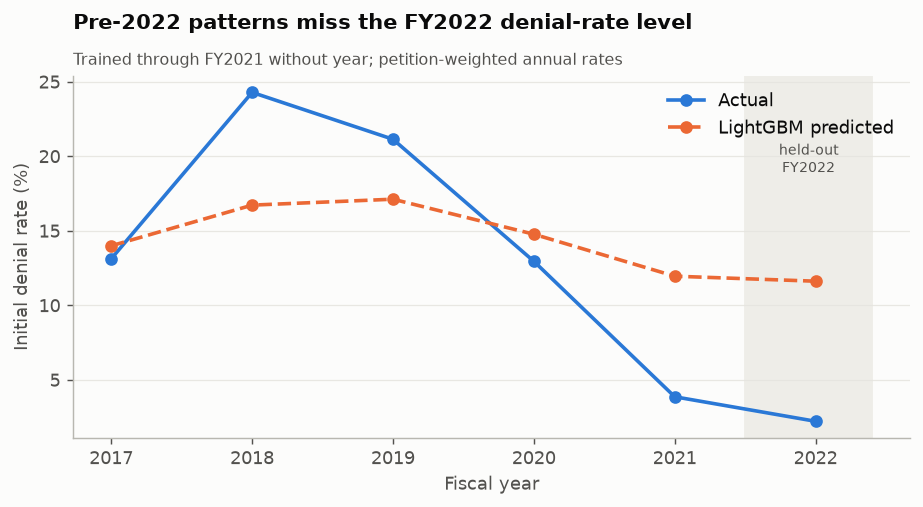

      actual  predicted
fy                     
2017   13.12      13.99
2018   24.28      16.72
2019   21.13      17.11
2020   12.95      14.76
2021    3.86      11.95
2022    2.21      11.61


In [7]:
pred_all_t = gbm_t.predict(Xg_t)
tmp = pd.DataFrame({"fy": fit_df.fy, "actual": y,
                    "pred": pred_all_t, "weight": weights})
byyr = tmp.groupby("fy").apply(
    lambda d: pd.Series({
        "actual": np.average(d.actual, weights=d.weight),
        "predicted": np.average(d.pred, weights=d.weight),
    }), include_groups=False) * 100

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(byyr.index, byyr.actual, color=C1, marker="o", markersize=6, label="Actual")
ax.plot(byyr.index, byyr.predicted, color=C2, marker="o", markersize=6,
        ls="--", label="LightGBM predicted")
ax.axvspan(2021.5, 2022.4, color="#eeede8", zorder=0)
ax.text(2021.95, byyr.values.max() * 0.78, "held-out\nFY2022", ha="center",
        fontsize=8, color=INK2)
ax.legend(loc="upper right")
finish(ax, "Pre-2022 patterns miss the FY2022 denial-rate level",
       "Trained through FY2021 without year; petition-weighted annual rates",
       "Fiscal year", "Initial denial rate (%)")
save("09_temporal_failure")

byyr.round(3).to_csv(TABLES / "temporal_actual_vs_predicted.csv")
print(byyr.round(2).to_string())

## 5. What drives within-period predictions

WLS coefficients provide adjusted associations and clustered uncertainty. SHAP values
summarize the final LightGBM model on the untouched sponsor-disjoint test rows.

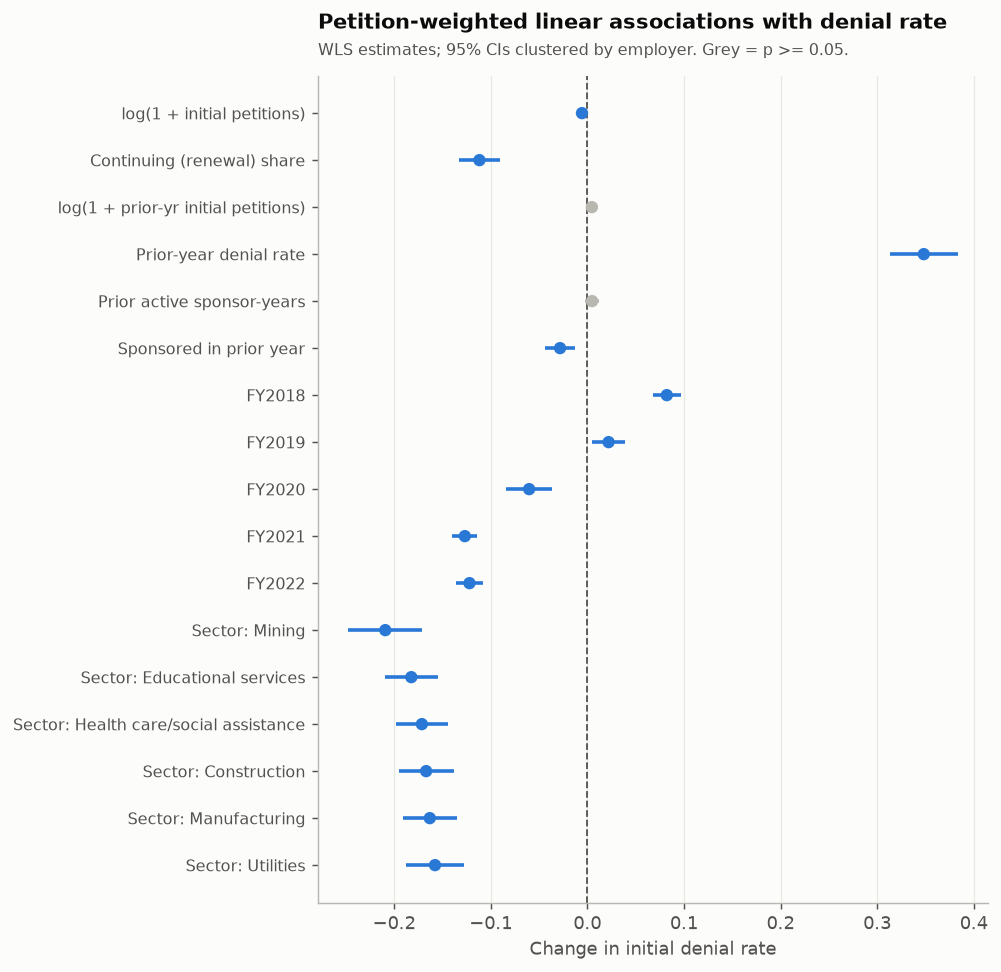

Selected WLS coefficients:
  log(1 + initial petitions)               -0.0055   p=0.00192
  Continuing (renewal) share               -0.1117   p=1.51e-24
  log(1 + prior-yr initial petitions)       0.0046   p=0.162
  Prior-year denial rate                    0.3482   p=6.25e-85
  Prior active sponsor-years                0.0049   p=0.188
  Sponsored in prior year                  -0.0283   p=0.000334


In [8]:
res = pd.DataFrame({"coef": wls.params, "lo": wls.conf_int()[0],
                    "hi": wls.conf_int()[1], "p": wls.pvalues}).drop("const")
res.to_csv(TABLES / "wls_coefficients.csv")

sector_rows = res[res.index.str.startswith("sector_")]
top_sectors = sector_rows.reindex(
    sector_rows.coef.abs().sort_values(ascending=False).index[:6])
show = pd.concat([res.loc[[c for c in res.index if c in PRETTY]],
                  res[res.index.str.startswith("fy_cat_")], top_sectors])
labels = [PRETTY.get(i, i.replace("fy_cat_", "FY").replace("sector_", "Sector: "))
          for i in show.index]

forest_plot(show, labels,
            "Petition-weighted linear associations with denial rate",
            "WLS estimates; 95% CIs clustered by employer. Grey = p >= 0.05.",
            "Change in initial denial rate", "06_forest_plot_ols")

print("Selected WLS coefficients:")
for k in NUMERIC:
    print(f"  {PRETTY[k]:40s} {wls.params[k]: .4f}   p={wls.pvalues[k]:.3g}")

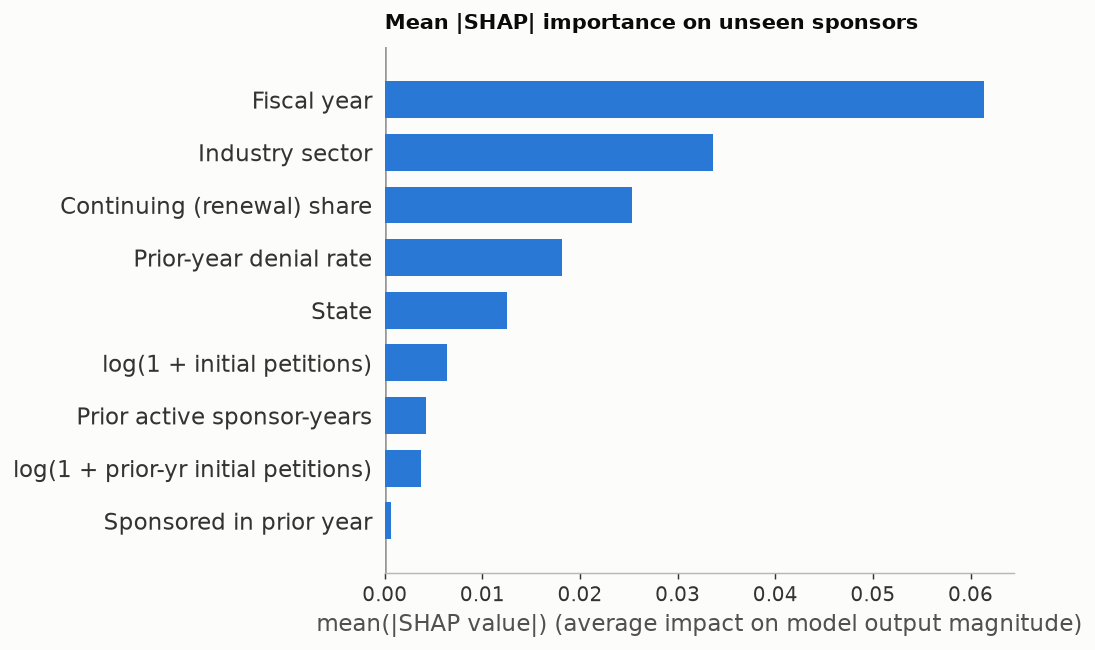

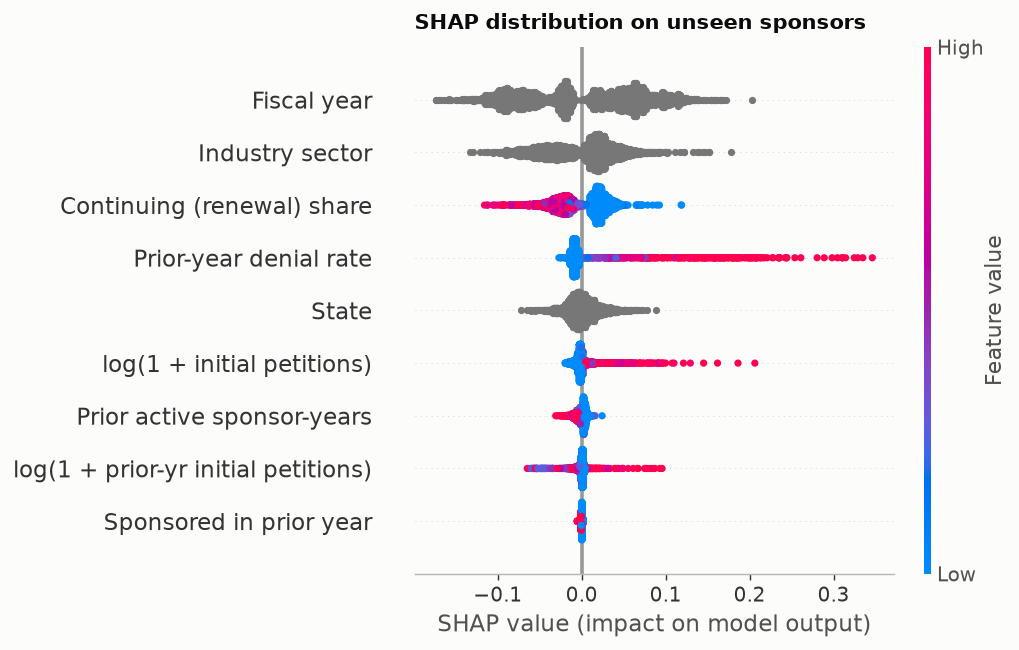

Fiscal year                            0.06138
Industry sector                        0.03363
Continuing (renewal) share             0.02529
Prior-year denial rate                 0.01811
State                                  0.01257
log(1 + initial petitions)             0.00639
Prior active sponsor-years             0.00424
log(1 + prior-yr initial petitions)    0.00370
Sponsored in prior year                0.00063


In [9]:
sample_n = min(4000, len(te))
samp_idx = pd.Series(te).sample(sample_n, random_state=SEED).to_numpy()
samp = X_gbm.iloc[samp_idx]
explainer = shap.TreeExplainer(gbm)
sv = explainer.shap_values(samp)
samp_named = samp.rename(columns=SHAP_NAMES)

plt.figure(figsize=(7.6, 4.6))
shap.summary_plot(sv, samp_named, plot_type="bar", show=False,
                  color=SEQ, max_display=12)
plt.title("Mean |SHAP| importance on unseen sponsors", loc="left",
          fontsize=11.5, color=INK)
save("07_shap_bar")

plt.figure(figsize=(7.6, 5.2))
shap.summary_plot(sv, samp_named, show=False, max_display=12)
plt.title("SHAP distribution on unseen sponsors", loc="left",
          fontsize=11.5, color=INK)
save("08_shap_beeswarm")

std_beta = (wls.params.drop("const") * X_lin.iloc[dev].std()) / y[dev].std()
lin_imp = std_beta.abs().sort_values(ascending=False).head(12)
gbm_imp = pd.Series(np.abs(sv).mean(0), index=samp_named.columns).sort_values(ascending=False)
lin_imp.to_csv(TABLES / "linear_importance.csv")
gbm_imp.to_csv(TABLES / "shap_importance.csv")
print(gbm_imp.round(5).to_string())

## 6. Does the wage block add predictive information?

Baseline and wage specifications use the same exact-match rows and the same sponsor-
disjoint partitions. Wage medians used for imputation are learned from training rows only.
This comparison isolates features from sample selection, although it cannot eliminate
selection into the matched sample itself.

In [10]:
fitw = panel[panel.lca_filings.notna() & panel.fy.isin(MODEL_YEARS)].copy()
fitw = fitw.reset_index(drop=True)
fitw["fy_cat"] = fitw.fy.astype(str)
fitw["log_wage_annual"] = np.log(fitw.wage_annual_med)
fitw["log_lca_filings"] = np.log1p(fitw.lca_filings)
fitw["soc2_modal"] = fitw.soc2_modal.fillna("UNKNOWN").astype(str)

trw, vaw, tew = group_partitions(fitw)
devw = np.sort(np.concatenate([trw, vaw]))
for c in WAGE_NUM:
    training_median = fitw.loc[trw, c].median()
    fitw[c] = fitw[c].fillna(training_median)

split_wage = split_diagnostic(fitw, trw, vaw, tew, "matched employer-years")
pd.concat([split_base, split_wage], ignore_index=True).to_csv(
    TABLES / "split_diagnostics.csv", index=False)

yw = fitw.denial_rate.to_numpy()
ywb = fitw.any_denial.to_numpy()
ww = fitw.initial_total.to_numpy(dtype=float)
gw = fitw.key.to_numpy()
print(f"\nmatched rows: {len(fitw):,} "
      f"({len(fitw) / len(fit_df):.1%} of model-window employer-years)")

matched employer-years
  train      rows=66,725 employers=34,805


  validation rows=16,719 employers=8,702
  test       rows=35,741 employers=18,646
  employer overlap across partitions: 0

matched rows: 119,185 (72.0% of model-window employer-years)


In [11]:
def fit_pair(numeric, categorical, label):
    '''Fit four models on a fixed matched sample and untouched test partition.'''
    Xl, Xg = design_matrices(fitw, numeric, categorical)
    model_wls = fit_wls(Xl, yw, ww, gw, devw)
    pred_wls = model_wls.predict(sm.add_constant(Xl.iloc[tew], has_constant="add"))
    r2_linear = r2_score(yw[tew], pred_wls, sample_weight=ww[tew])

    model_gbm, trees_reg = tune_refit_regressor(Xg, yw, ww, trw, vaw, devw)
    r2_tree = r2_score(yw[tew], model_gbm.predict(Xg.iloc[tew]),
                       sample_weight=ww[tew])

    model_logit = LogisticRegression(max_iter=3000)
    model_logit.fit(Xl.iloc[devw], ywb[devw])
    auc_linear = roc_auc_score(
        ywb[tew], model_logit.predict_proba(Xl.iloc[tew])[:, 1])

    model_clf, trees_clf = tune_refit_classifier(Xg, ywb, trw, vaw, devw)
    auc_tree = roc_auc_score(ywb[tew], model_clf.predict_proba(Xg.iloc[tew])[:, 1])

    print(f"{label:22s} WLS R2={r2_linear:.4f}; LGBM R2={r2_tree:.4f}; "
          f"Logit AUC={auc_linear:.4f}; LGBM AUC={auc_tree:.4f}")
    return dict(label=label, r2_wls=r2_linear, r2_gbm=r2_tree,
                auc_logit=auc_linear, auc_gbm=auc_tree, wls=model_wls,
                gbm=model_gbm, X_lin=Xl, X_gbm=Xg,
                trees_reg=trees_reg, trees_clf=trees_clf)


base = fit_pair(NUMERIC, CATEG, "Baseline (no wages)")
full = fit_pair(NUMERIC + WAGE_NUM, CATEG + WAGE_CAT, "With wage features")

comp2 = pd.DataFrame(
    [{"Model": "WLS / Logistic", "Features": m["label"],
      "Petition-weighted R2": round(m["r2_wls"], 4),
      "AUC": round(m["auc_logit"], 4)} for m in (base, full)] +
    [{"Model": "LightGBM", "Features": m["label"],
      "Petition-weighted R2": round(m["r2_gbm"], 4),
      "AUC": round(m["auc_gbm"], 4)} for m in (base, full)])
comp2.to_csv(TABLES / "model_comparison_wages.csv", index=False)
print("\n" + comp2.to_string(index=False))

Baseline (no wages)    WLS R2=0.3530; LGBM R2=0.4771; Logit AUC=0.8260; LGBM AUC=0.8356


With wage features     WLS R2=0.3821; LGBM R2=0.5283; Logit AUC=0.8421; LGBM AUC=0.8537

         Model            Features  Petition-weighted R2    AUC
WLS / Logistic Baseline (no wages)                0.3530 0.8260
WLS / Logistic  With wage features                0.3821 0.8421
      LightGBM Baseline (no wages)                0.4771 0.8356
      LightGBM  With wage features                0.5283 0.8537


### Wage coefficients and tree importance

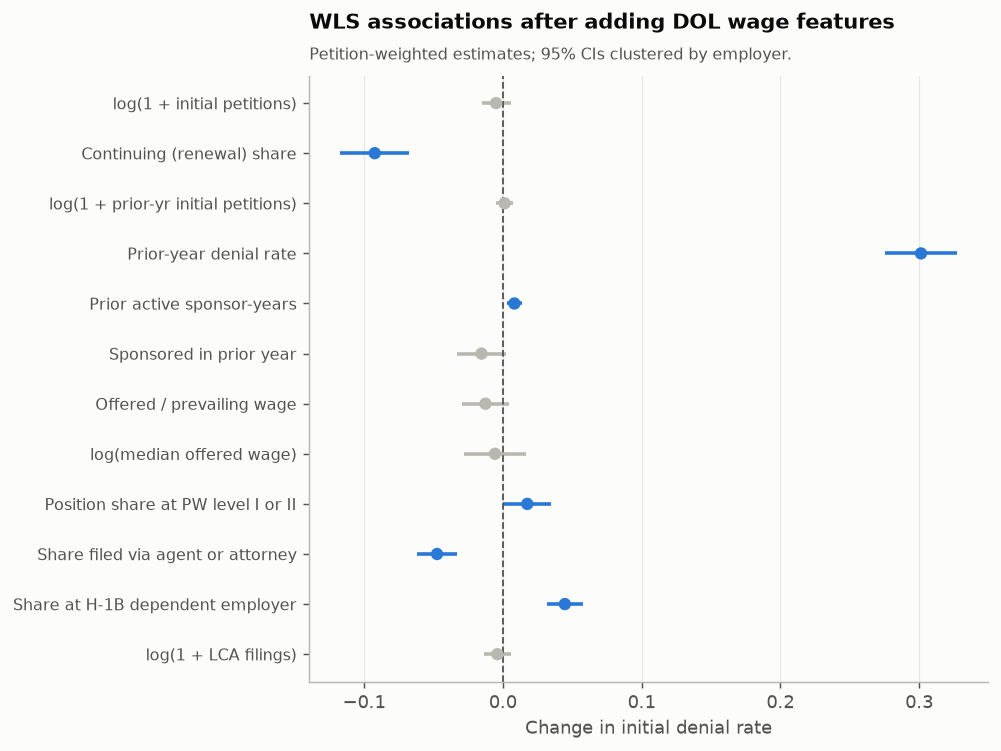

Wage-feature coefficients:
  Offered / prevailing wage                -0.0125   p=0.141
  log(median offered wage)                 -0.0056   p=0.621
  Position share at PW level I or II        0.0176   p=0.0444
  Share filed via agent or attorney        -0.0474   p=1.01e-10
  Share at H-1B dependent employer          0.0447   p=5.87e-12
  log(1 + LCA filings)                     -0.0040   p=0.434


In [12]:
model_w = full["wls"]
res_w = pd.DataFrame({"coef": model_w.params, "lo": model_w.conf_int()[0],
                      "hi": model_w.conf_int()[1], "p": model_w.pvalues}).drop("const")
res_w.to_csv(TABLES / "wls_coefficients_wages.csv")
order = [c for c in PRETTY if c in res_w.index]
show_w = res_w.loc[order]

forest_plot(show_w, [PRETTY[i] for i in show_w.index],
            "WLS associations after adding DOL wage features",
            "Petition-weighted estimates; 95% CIs clustered by employer.",
            "Change in initial denial rate", "13_forest_plot_wages")

print("Wage-feature coefficients:")
for k in WAGE_NUM:
    print(f"  {PRETTY[k]:40s} {model_w.params[k]: .4f}   p={model_w.pvalues[k]:.3g}")

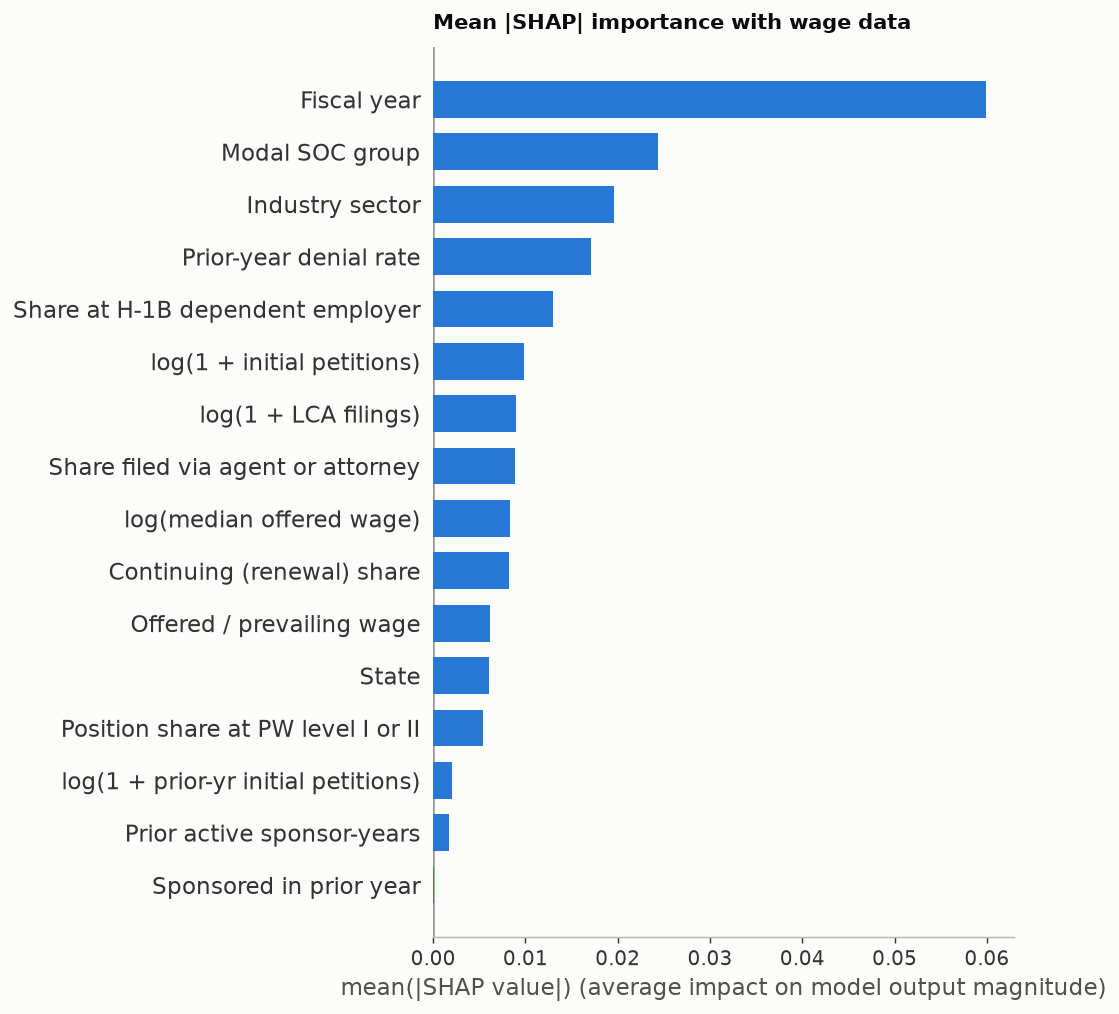

Fiscal year                            0.05994
Modal SOC group                        0.02440
Industry sector                        0.01955
Prior-year denial rate                 0.01705
Share at H-1B dependent employer       0.01304
log(1 + initial petitions)             0.00985
log(1 + LCA filings)                   0.00894
Share filed via agent or attorney      0.00885
log(median offered wage)               0.00829
Continuing (renewal) share             0.00822
Offered / prevailing wage              0.00614
State                                  0.00606
Position share at PW level I or II     0.00541
log(1 + prior-yr initial petitions)    0.00201
Prior active sponsor-years             0.00176
Sponsored in prior year                0.00012


In [13]:
sample_n_w = min(4000, len(tew))
samp_idx_w = pd.Series(tew).sample(sample_n_w, random_state=SEED).to_numpy()
samp_w = full["X_gbm"].iloc[samp_idx_w]
explainer_w = shap.TreeExplainer(full["gbm"])
sv_w = explainer_w.shap_values(samp_w)
samp_w_named = samp_w.rename(columns=SHAP_NAMES)

plt.figure(figsize=(7.6, 5.2))
shap.summary_plot(sv_w, samp_w_named, plot_type="bar", show=False,
                  color=SEQ, max_display=16)
plt.title("Mean |SHAP| importance with wage data", loc="left",
          fontsize=11.5, color=INK)
save("14_shap_bar_wages")

gbm_imp_w = pd.Series(
    np.abs(sv_w).mean(0), index=samp_w_named.columns).sort_values(ascending=False)
gbm_imp_w.to_csv(TABLES / "shap_importance_wages.csv")
print(gbm_imp_w.round(5).to_string())

## Interpretation

The executed tables provide three distinct estimates: generalization to unseen sponsors
within familiar fiscal years, transfer into a future policy year, and the incremental
value of wage data among exact agency matches. Keeping those estimands separate prevents
a strong within-period score from being mistaken for durable forward prediction.